All libraries are ready to use!

--------------------------------------------------
PART 1 - Please upload your training_sets.zip file
--------------------------------------------------


Saving training_sets.zip to training_sets.zip
File received: training_sets.zip
Files extracted successfully!

--------------------------------------------------
PART 2 - Reading patient files...
--------------------------------------------------
Total patients loaded: 5000
Total rows in dataset  : 194835
Total columns          : 42
Sepsis cases found     : 4267

--------------------------------------------------
PART 3 - Exploring the data
--------------------------------------------------

Columns with most missing values (top 10):
EtCO2               100.0
TroponinI            99.9
Bilirubin_direct     99.8
Fibrinogen           99.2
Bilirubin_total      98.8
Alkalinephos         98.5
AST                  98.5
Lactate              96.5
PTT                  95.2
Calcium              95.1
dtype: float64


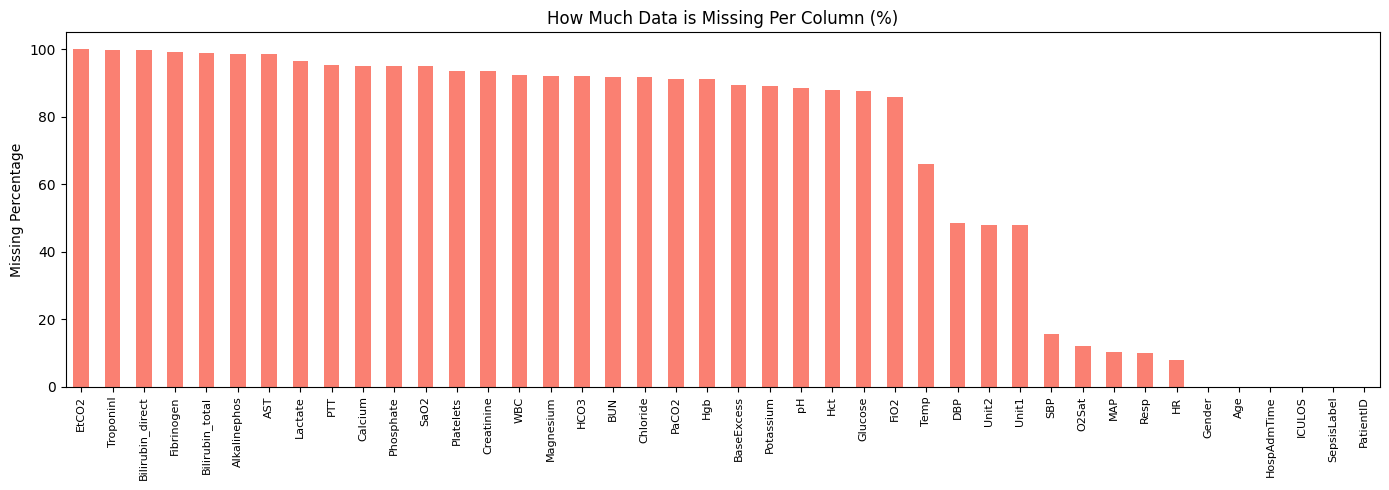

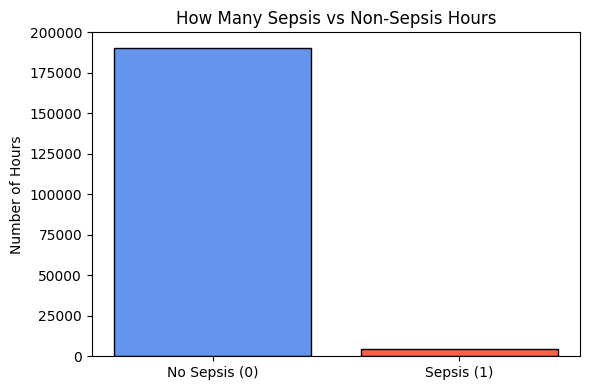

Charts saved!

--------------------------------------------------
PART 4 - Fixing noisy labels for 6-hour early warning
--------------------------------------------------
Original sepsis labels     : 4267
New early-warning labels   : 2707
Labels have been shifted 6 hours back!

--------------------------------------------------
PART 5 - Preparing and engineering features
--------------------------------------------------
Processing features (this takes about 1 minute)...
Total number of features ready: 47
Feature preparation done!

--------------------------------------------------
PART 6 - Splitting data (by patient to avoid leakage)
--------------------------------------------------
Training rows   : 156272
Validation rows : 38563
Sepsis rate in training   : 1.5%
Sepsis rate in validation : 1.1%

Balancing classes with SMOTE...
Before balancing: [154004   2268]
After  balancing: [154004 154004]
Data is ready for training!

--------------------------------------------------
PART 7 - T

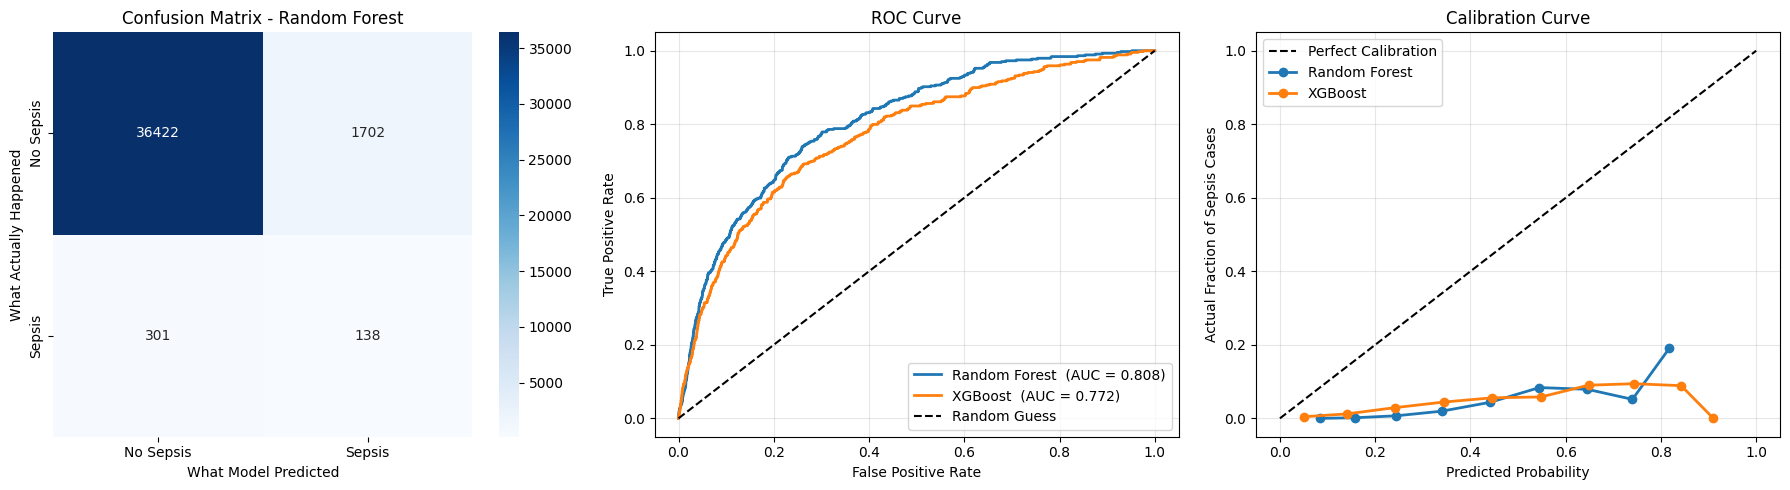


Classification Report:
              precision    recall  f1-score   support

   No Sepsis       0.99      0.96      0.97     38124
      Sepsis       0.07      0.31      0.12       439

    accuracy                           0.95     38563
   macro avg       0.53      0.63      0.55     38563
weighted avg       0.98      0.95      0.96     38563

Charts saved!

--------------------------------------------------
PART 10 - Upload a CSV file to test on a new patient
--------------------------------------------------

Your CSV file needs these columns (same as training data):
HR, O2Sat, Temp, SBP, MAP, DBP, Resp, BaseExcess, HCO3,
FiO2, pH, PaCO2, SaO2, AST, BUN, Alkalinephos, Calcium,
Chloride, Creatinine, Glucose, Lactate, Magnesium, Potassium,
WBC, Platelets, Hct, Hgb, Age, Gender, HospAdmTime, ICULOS

Each row = one hour of the patient's stay in ICU.
Tip: You can just rename any .psv file from your zip to .csv

Please upload your test CSV file now...


Streaming output truncated to the last 5000 lines.
       28           24.1   No Sepsis        LOW
       29           25.0   No Sepsis        LOW
       30           25.4   No Sepsis        LOW
       31           24.4   No Sepsis        LOW
       32           26.0   No Sepsis        LOW
       33           25.2   No Sepsis        LOW
       34           24.3   No Sepsis        LOW
       35           26.3   No Sepsis        LOW
       36           24.0   No Sepsis        LOW
       37           20.2   No Sepsis        LOW
       38           21.5   No Sepsis        LOW
       39           23.7   No Sepsis        LOW
       40           26.9   No Sepsis        LOW
       41           27.7   No Sepsis        LOW
        1           24.7   No Sepsis        LOW
        2           23.6   No Sepsis        LOW
        3           25.3   No Sepsis        LOW
        4           22.1   No Sepsis        LOW
        5           30.1   No Sepsis        LOW
        6           21.5   No Sepsis 

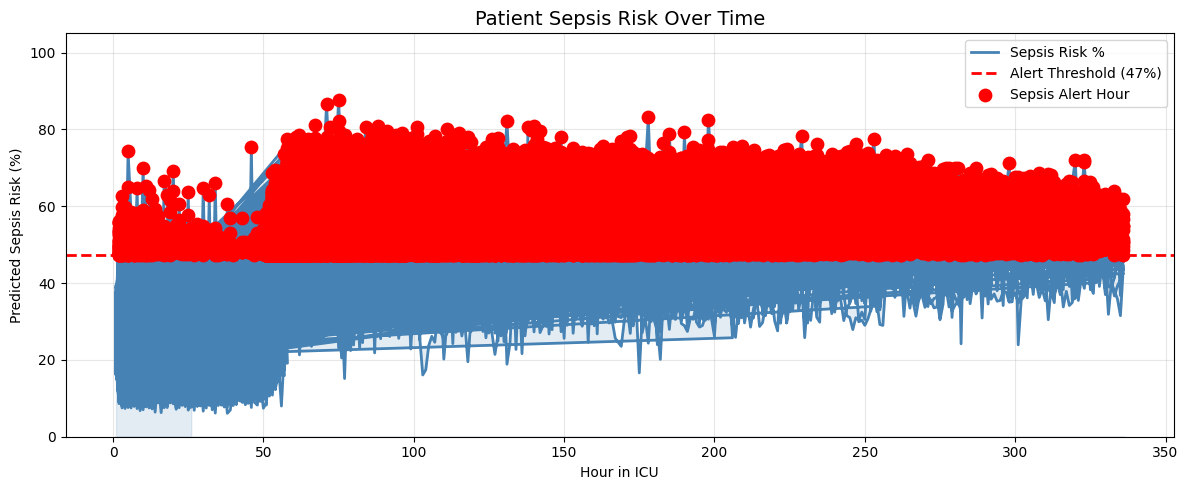

Chart saved as patient_risk_chart.png

--------------------------------------------------
PART 14 - Accuracy check (SepsisLabel column found)
--------------------------------------------------
AUC Score on your file : 0.7476

Confusion Matrix:
[[1461614   62680]
 [  19999    7917]]

Detailed Report:
              precision    recall  f1-score   support

   No Sepsis       0.99      0.96      0.97   1524294
      Sepsis       0.11      0.28      0.16     27916

    accuracy                           0.95   1552210
   macro avg       0.55      0.62      0.57   1552210
weighted avg       0.97      0.95      0.96   1552210


ALL DONE!

Files saved:
  missing_values_chart.png    - shows missing data
  class_balance_chart.png     - shows class distribution
  model_evaluation_charts.png - confusion matrix, ROC, calibration
  patient_risk_chart.png      - your patient's risk over time

Best model : Random Forest
AUC Score  : 0.8084

Tip: To use the full 20000 patients instead of 5000,
     cha

In [1]:
# ============================================================
#   Sepsis Early Warning System
#   This project predicts sepsis 6 hours before it happens
#   using ICU patient data from PhysioNet Challenge 2019
#   Built for Google Colab
# ============================================================


import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

print("All libraries are ready to use!")


# ============================================================
#   PART 1 - UPLOAD THE TRAINING DATA (ZIP FILE)
# ============================================================
# The training data is a zip file containing thousands of
# small patient files. Each file is one patient's ICU stay.
# Each row in that file is one hour of that patient's data.

print("\n" + "-"*50)
print("PART 1 - Please upload your training_sets.zip file")
print("-"*50)

uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]
print("File received:", zip_filename)

# Unzip the file so we can read the patient files inside
with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall('training_data')

print("Files extracted successfully!")


# ============================================================
#   PART 2 - READ ALL PATIENT FILES
# ============================================================
# We go through the extracted folder and read each .psv file
# psv means pipe-separated values (columns separated by |)
# We give each patient a number so we can tell them apart

print("\n" + "-"*50)
print("PART 2 - Reading patient files...")
print("-"*50)

def read_patient_files(folder, limit=5000):
    # This function reads up to 'limit' patient files
    # and combines them into one big table
    all_data = []
    count    = 0

    for root, dirs, file_list in os.walk(folder):
        for filename in sorted(file_list):
            if filename.endswith('.psv'):
                full_path = os.path.join(root, filename)
                try:
                    one_patient = pd.read_csv(full_path, sep='|')
                    one_patient['PatientID'] = count
                    all_data.append(one_patient)
                    count += 1
                except:
                    continue  # skip any file that has a problem

            if count >= limit:
                break
        if count >= limit:
            break

    print(f"Total patients loaded: {count}")
    return pd.concat(all_data, ignore_index=True)

# Load 5000 patients (change to 20000 for full dataset - takes longer)
data = read_patient_files('training_data', limit=5000)

print(f"Total rows in dataset  : {len(data)}")
print(f"Total columns          : {len(data.columns)}")
print(f"Sepsis cases found     : {data['SepsisLabel'].sum()}")


# ============================================================
#   PART 3 - EXPLORE THE DATA
# ============================================================
# Before building a model, it is good to understand the data
# We check how many values are missing and how balanced the labels are

print("\n" + "-"*50)
print("PART 3 - Exploring the data")
print("-"*50)

# How much data is missing in each column?
missing = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)
print("\nColumns with most missing values (top 10):")
print(missing.head(10).round(1))

# Draw a chart showing missing values
plt.figure(figsize=(14, 5))
missing.plot(kind='bar', color='salmon')
plt.title('How Much Data is Missing Per Column (%)')
plt.ylabel('Missing Percentage')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig('missing_values_chart.png', dpi=100)
plt.show()

# How many sepsis vs non-sepsis hours do we have?
plt.figure(figsize=(6, 4))
counts = data['SepsisLabel'].value_counts()
plt.bar(['No Sepsis (0)', 'Sepsis (1)'], counts.values,
        color=['cornflowerblue', 'tomato'], edgecolor='black')
plt.title('How Many Sepsis vs Non-Sepsis Hours')
plt.ylabel('Number of Hours')
plt.tight_layout()
plt.savefig('class_balance_chart.png', dpi=100)
plt.show()

print("Charts saved!")


# ============================================================
#   PART 4 - FIX THE NOISY LABELS
# ============================================================
# Doctors sometimes record sepsis diagnosis late in the system
# So a patient who got sepsis at hour 20 might have the label
# recorded at hour 23 or 24 — this is called label noise
#
# To fix this AND to predict sepsis early (6 hours ahead),
# we shift the label backwards by 6 hours
# So if sepsis happened at hour 20, we mark hours 14 to 20
# as positive — this trains the model to warn us early

print("\n" + "-"*50)
print("PART 4 - Fixing noisy labels for 6-hour early warning")
print("-"*50)

def add_early_warning_labels(df, hours_before=6):
    df = df.copy()
    df['EarlyLabel'] = 0  # start with all zeros

    for pid in df['PatientID'].unique():
        patient_rows = df[df['PatientID'] == pid]

        # Find when sepsis first appeared for this patient
        sepsis_times = patient_rows[patient_rows['SepsisLabel'] == 1]['ICULOS'].values

        if len(sepsis_times) > 0:
            first_sepsis_hour = sepsis_times.min()
            warning_start     = max(0, first_sepsis_hour - hours_before)

            # Mark those hours as early warning (label = 1)
            condition = (
                (df['PatientID'] == pid) &
                (df['ICULOS']    >= warning_start) &
                (df['ICULOS']    <= first_sepsis_hour)
            )
            df.loc[condition, 'EarlyLabel'] = 1

    return df

data = add_early_warning_labels(data, hours_before=6)

print(f"Original sepsis labels     : {data['SepsisLabel'].sum()}")
print(f"New early-warning labels   : {data['EarlyLabel'].sum()}")
print("Labels have been shifted 6 hours back!")


# ============================================================
#   PART 5 - PREPARE FEATURES
# ============================================================
# We need to:
# 1. Fill in the missing values (up to 60% missing per patient!)
# 2. Create extra helpful features like rolling averages
# 3. Add a simple "how sick does this patient look" score

print("\n" + "-"*50)
print("PART 5 - Preparing and engineering features")
print("-"*50)

# These are the groups of columns we will use
vital_signs = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']

lab_results = ['BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2',
               'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride',
               'Creatinine', 'Glucose', 'Lactate', 'Magnesium',
               'Potassium', 'WBC', 'Platelets', 'Hct', 'Hgb']

patient_info = ['Age', 'Gender', 'HospAdmTime', 'ICULOS']

all_columns = vital_signs + lab_results + patient_info


def prepare_features(df):
    df = df.copy()

    # Step 1: Fill missing values
    # For each patient, carry forward the last known value
    # then fill any remaining gaps with the column average
    df[all_columns] = df.groupby('PatientID')[all_columns].transform(
        lambda col: col.ffill().bfill()
    )
    for col in all_columns:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # Step 2: Rolling averages for vital signs
    # We look at the last 3 hours to spot trends
    for col in vital_signs:
        df[col + '_avg3h'] = df.groupby('PatientID')[col].transform(
            lambda x: x.rolling(window=3, min_periods=1).mean()
        )
        df[col + '_std3h'] = df.groupby('PatientID')[col].transform(
            lambda x: x.rolling(window=3, min_periods=1).std().fillna(0)
        )

    # Step 3: How much data is missing in this row?
    # A row with lots of missing values might mean the patient
    # is too sick to take measurements — useful signal!
    df['how_much_missing'] = (
        df[vital_signs + lab_results].isnull().mean(axis=1)
    )

    # Step 4: Simple severity score (like a quick clinical check)
    # Count how many warning signs are present
    df['severity_score'] = (
        (df['Resp'] > 22).astype(int)   +   # fast breathing
        (df['HR']   > 100).astype(int)  +   # fast heart rate
        (df['Temp'] > 38.3).astype(int) +   # fever
        (df['SBP']  < 100).astype(int)  +   # low blood pressure
        (df['WBC']  > 12).astype(int)       # high white blood cells
    )

    return df

print("Processing features (this takes about 1 minute)...")
data = prepare_features(data)

# Build the complete list of features we will use for training
rolling_cols  = ([c + '_avg3h' for c in vital_signs] +
                 [c + '_std3h' for c in vital_signs])
extra_cols    = ['how_much_missing', 'severity_score']
feature_list  = all_columns + rolling_cols + extra_cols

print(f"Total number of features ready: {len(feature_list)}")
print("Feature preparation done!")


# ============================================================
#   PART 6 - SPLIT DATA INTO TRAINING AND VALIDATION
# ============================================================
# Very important: we split by PATIENT, not by row
# If we split by row, the model might see future hours of a
# patient during training and test on past hours — this is
# called data leakage and gives fake-good results

print("\n" + "-"*50)
print("PART 6 - Splitting data (by patient to avoid leakage)")
print("-"*50)

all_patient_ids            = data['PatientID'].unique()
train_ids, val_ids         = train_test_split(all_patient_ids,
                                               test_size=0.2,
                                               random_state=42)

train_data = data[data['PatientID'].isin(train_ids)]
val_data   = data[data['PatientID'].isin(val_ids)]

X_train = train_data[feature_list].values
y_train = train_data['EarlyLabel'].values
X_val   = val_data[feature_list].values
y_val   = val_data['EarlyLabel'].values

print(f"Training rows   : {len(X_train)}")
print(f"Validation rows : {len(X_val)}")
print(f"Sepsis rate in training   : {y_train.mean()*100:.1f}%")
print(f"Sepsis rate in validation : {y_val.mean()*100:.1f}%")

# Scale the numbers so all features are on the same scale
# We fit the scaler on training data only — not on validation
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# Balance the training data using SMOTE
# Sepsis is rare — about 5-10% of hours — so we create
# synthetic sepsis examples to help the model learn better
print("\nBalancing classes with SMOTE...")
smote              = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"Before balancing: {np.bincount(y_train)}")
print(f"After  balancing: {np.bincount(y_train_bal)}")
print("Data is ready for training!")


# ============================================================
#   PART 7 - TRAIN THE MODELS
# ============================================================
# We train two different models and compare them
# Model 1: Random Forest - builds many decision trees
# Model 2: XGBoost - a powerful boosting algorithm

print("\n" + "-"*50)
print("PART 7 - Training the models")
print("-"*50)

# Random Forest
print("\nTraining Random Forest model...")
rf = RandomForestClassifier(
    n_estimators   = 100,    # 100 trees
    max_depth      = 10,     # trees can go 10 levels deep
    min_samples_leaf = 5,    # each leaf needs at least 5 samples
    class_weight   = 'balanced',
    random_state   = 42,
    n_jobs         = -1      # use all CPU cores
)
rf.fit(X_train_bal, y_train_bal)
print("Random Forest is trained!")

# XGBoost
print("\nTraining XGBoost model...")
xgb = XGBClassifier(
    n_estimators     = 200,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)
xgb.fit(
    X_train_bal, y_train_bal,
    eval_set  = [(X_val_scaled, y_val)],
    verbose   = False
)
print("XGBoost is trained!")


# ============================================================
#   PART 8 - EVALUATE ON VALIDATION DATA
# ============================================================
# Now we check how well the models perform on data they
# have never seen before

print("\n" + "-"*50)
print("PART 8 - Checking model performance")
print("-"*50)

rf_probs  = rf.predict_proba(X_val_scaled)[:, 1]
xgb_probs = xgb.predict_proba(X_val_scaled)[:, 1]

rf_auc  = roc_auc_score(y_val, rf_probs)
xgb_auc = roc_auc_score(y_val, xgb_probs)

print(f"\nRandom Forest  AUC score : {rf_auc:.4f}")
print(f"XGBoost        AUC score : {xgb_auc:.4f}")

# Use the better model going forward
if xgb_auc >= rf_auc:
    best_model = xgb
    best_probs = xgb_probs
    best_name  = "XGBoost"
    best_auc   = xgb_auc
else:
    best_model = rf
    best_probs = rf_probs
    best_name  = "Random Forest"
    best_auc   = rf_auc

print(f"\nBest model selected: {best_name} (AUC = {best_auc:.4f})")

# Find the best decision threshold
# Instead of always using 0.5, we find the threshold that
# gives the best F1 score — important for imbalanced data
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_val, best_probs)
f1_arr     = 2 * (prec_arr * rec_arr) / (prec_arr + rec_arr + 1e-9)
best_index = np.argmax(f1_arr)
best_threshold = (thresh_arr[best_index]
                  if best_index < len(thresh_arr) else 0.35)

print(f"Best decision threshold  : {best_threshold:.3f}")

y_pred_val = (best_probs >= best_threshold).astype(int)


# ============================================================
#   PART 9 - DRAW THE RESULT CHARTS
# ============================================================

print("\n" + "-"*50)
print("PART 9 - Drawing result charts")
print("-"*50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Confusion Matrix
cm = confusion_matrix(y_val, y_pred_val)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Sepsis', 'Sepsis'],
            yticklabels=['No Sepsis', 'Sepsis'])
axes[0].set_title(f'Confusion Matrix - {best_name}')
axes[0].set_xlabel('What Model Predicted')
axes[0].set_ylabel('What Actually Happened')

# Chart 2: ROC Curve
for probs, name, auc in zip(
        [rf_probs, xgb_probs],
        ['Random Forest', 'XGBoost'],
        [rf_auc, xgb_auc]):
    fpr, tpr, _ = roc_curve(y_val, probs)
    axes[1].plot(fpr, tpr, lw=2, label=f'{name}  (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Chart 3: Calibration Curve
# This shows whether the predicted probabilities are reliable
# A well-calibrated model means "70% probability" really
# means the event happens ~70% of the time
axes[2].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
for probs, name in zip([rf_probs, xgb_probs],
                        ['Random Forest', 'XGBoost']):
    frac, mean_p = calibration_curve(y_val, probs, n_bins=10)
    axes[2].plot(mean_p, frac, marker='o', lw=2, label=name)
axes[2].set_title('Calibration Curve')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_ylabel('Actual Fraction of Sepsis Cases')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation_charts.png', dpi=100)
plt.show()

print("\nClassification Report:")
print(classification_report(y_val, y_pred_val,
      target_names=['No Sepsis', 'Sepsis']))
print("Charts saved!")


# ============================================================
#   PART 10 - UPLOAD A CSV FILE TO TEST ON NEW PATIENT
# ============================================================
# Now the model is trained. You can upload any CSV file
# that has the same columns as the training data and the
# model will predict sepsis risk hour by hour.
#
# HOW TO GET A TEST CSV:
# Just take any .psv file from your zip and rename it to .csv
# Or use any patient data file with the same column names.

print("\n" + "-"*50)
print("PART 10 - Upload a CSV file to test on a new patient")
print("-"*50)
print("""
Your CSV file needs these columns (same as training data):
HR, O2Sat, Temp, SBP, MAP, DBP, Resp, BaseExcess, HCO3,
FiO2, pH, PaCO2, SaO2, AST, BUN, Alkalinephos, Calcium,
Chloride, Creatinine, Glucose, Lactate, Magnesium, Potassium,
WBC, Platelets, Hct, Hgb, Age, Gender, HospAdmTime, ICULOS

Each row = one hour of the patient's stay in ICU.
Tip: You can just rename any .psv file from your zip to .csv
""")

print("Please upload your test CSV file now...")
test_upload   = files.upload()
test_filename = list(test_upload.keys())[0]
print(f"Test file received: {test_filename}")


# ============================================================
#   PART 11 - PREPARE THE TEST FILE AND PREDICT
# ============================================================

print("\n" + "-"*50)
print("PART 11 - Running predictions on your file")
print("-"*50)

# Try loading as pipe-separated first, then comma-separated
try:
    test_df = pd.read_csv(test_filename, sep='|')
    if test_df.shape[1] <= 1:
        test_df = pd.read_csv(test_filename, sep=',')
except:
    test_df = pd.read_csv(test_filename, sep=',')

print(f"Rows in your file  : {len(test_df)}")
print(f"Columns found      : {len(test_df.columns)}")

# Add PatientID and ICULOS if they are not in the file
if 'PatientID' not in test_df.columns:
    test_df['PatientID'] = 0
if 'ICULOS' not in test_df.columns:
    test_df['ICULOS'] = range(1, len(test_df) + 1)


def prepare_test_file(df):
    df = df.copy()

    # Fill in missing values using available data
    for col in all_columns:
        if col in df.columns:
            col_median = df[col].median()
            if pd.isna(col_median):
                col_median = 0
            df[col] = df[col].fillna(col_median)
        else:
            df[col] = 0  # column does not exist — use zero

    # Add rolling average features
    for col in vital_signs:
        df[col + '_avg3h'] = (
            df[col].rolling(window=3, min_periods=1).mean()
        )
        df[col + '_std3h'] = (
            df[col].rolling(window=3, min_periods=1).std().fillna(0)
        )

    # Missing rate per row
    df['how_much_missing'] = (
        df[vital_signs + lab_results].isnull().mean(axis=1)
    )

    # Severity score
    df['severity_score'] = (
        (df.get('Resp', pd.Series([0]*len(df))) > 22).astype(int) +
        (df.get('HR',   pd.Series([0]*len(df))) > 100).astype(int) +
        (df.get('Temp', pd.Series([0]*len(df))) > 38.3).astype(int) +
        (df.get('SBP',  pd.Series([0]*len(df))) < 100).astype(int) +
        (df.get('WBC',  pd.Series([0]*len(df))) > 12).astype(int)
    )

    return df

test_df = prepare_test_file(test_df)

# Make sure all needed columns exist
for col in feature_list:
    if col not in test_df.columns:
        test_df[col] = 0

# Get feature matrix and scale it
X_new        = test_df[feature_list].values
X_new        = np.nan_to_num(X_new, nan=0.0)
X_new_scaled = scaler.transform(X_new)  # use same scaler from training

# Run the prediction
predicted_probs = best_model.predict_proba(X_new_scaled)[:, 1]
predicted_class = (predicted_probs >= best_threshold).astype(int)


# ============================================================
#   PART 12 - SHOW THE RESULTS
# ============================================================

print("\n" + "-"*50)
print("PART 12 - Prediction Results")
print("-"*50)

# Build a nice results table
results = pd.DataFrame({
    'ICU Hour'       : test_df['ICULOS'].values,
    'Risk Prob (%)'  : (predicted_probs * 100).round(1),
    'Prediction'     : ['SEPSIS RISK' if p == 1
                        else 'No Sepsis' for p in predicted_class],
    'Risk Level'     : ['HIGH'   if p >= 0.70 else
                        'MEDIUM' if p >= 0.40 else
                        'LOW'    for p in predicted_probs]
})

print("\n")
print(results.to_string(index=False))

# Summary numbers
total_hrs  = len(predicted_class)
risk_hrs   = int(predicted_class.sum())
peak_prob  = predicted_probs.max() * 100
peak_hr    = test_df['ICULOS'].values[predicted_probs.argmax()]

print(f"""
Summary
-------
Total hours checked     : {total_hrs}
Hours with sepsis risk  : {risk_hrs}
Highest risk probability: {peak_prob:.1f}%
Hour of highest risk    : {peak_hr}
Model used              : {best_name}
Decision threshold      : {best_threshold:.3f}
""")

if risk_hrs > 0:
    print("WARNING: Sepsis risk has been detected.")
    print("Please alert the medical team for further evaluation.")
else:
    print("No sepsis risk detected in this patient's stay.")


# ============================================================
#   PART 13 - DRAW PREDICTION CHART FOR THIS PATIENT
# ============================================================

print("\n" + "-"*50)
print("PART 13 - Drawing prediction chart")
print("-"*50)

hours = test_df['ICULOS'].values

plt.figure(figsize=(12, 5))
plt.plot(hours, predicted_probs * 100,
         color='steelblue', lw=2, label='Sepsis Risk %')
plt.fill_between(hours, predicted_probs * 100,
                 alpha=0.15, color='steelblue')
plt.axhline(y=best_threshold * 100,
            color='red', linestyle='--', lw=2,
            label=f'Alert Threshold ({best_threshold*100:.0f}%)')

# Highlight hours where sepsis risk was triggered
risky_hours = hours[predicted_class == 1]
risky_probs = predicted_probs[predicted_class == 1]
if len(risky_hours) > 0:
    plt.scatter(risky_hours, risky_probs * 100,
                color='red', s=80, zorder=5, label='Sepsis Alert Hour')

plt.title('Patient Sepsis Risk Over Time', fontsize=14)
plt.xlabel('Hour in ICU')
plt.ylabel('Predicted Sepsis Risk (%)')
plt.legend()
plt.ylim(0, 105)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('patient_risk_chart.png', dpi=100)
plt.show()
print("Chart saved as patient_risk_chart.png")


# ============================================================
#   PART 14 - IF YOUR CSV HAS TRUE LABELS, CHECK ACCURACY
# ============================================================
# If your test CSV has a SepsisLabel column, we can also
# measure how accurate the predictions were

if 'SepsisLabel' in test_df.columns:
    print("\n" + "-"*50)
    print("PART 14 - Accuracy check (SepsisLabel column found)")
    print("-"*50)

    true_labels = test_df['SepsisLabel'].values

    try:
        test_auc = roc_auc_score(true_labels, predicted_probs)
        print(f"AUC Score on your file : {test_auc:.4f}")

        print("\nConfusion Matrix:")
        print(confusion_matrix(true_labels, predicted_class))

        print("\nDetailed Report:")
        print(classification_report(true_labels, predicted_class,
              target_names=['No Sepsis', 'Sepsis']))

    except Exception as problem:
        print(f"Could not compute accuracy: {problem}")

else:
    print("\nNote: No SepsisLabel column found in your file.")
    print("The predictions above are the final output.")


# ============================================================
#   DONE!
# ============================================================
print("\n" + "="*50)
print("ALL DONE!")
print("="*50)
print(f"""
Files saved:
  missing_values_chart.png    - shows missing data
  class_balance_chart.png     - shows class distribution
  model_evaluation_charts.png - confusion matrix, ROC, calibration
  patient_risk_chart.png      - your patient's risk over time

Best model : {best_name}
AUC Score  : {best_auc:.4f}

Tip: To use the full 20000 patients instead of 5000,
     change limit=5000 to limit=20000 in Part 2.
     This gives better accuracy but takes about 10 minutes.
""")